# Quantifing Uncertainty of Turbulence Statistics and their Derived Parameters

Given what I observed, how uncertain is my estimate due to randomness? We want an error bar/confidence interval to express this uncertainty.

In the case of turbulence analysis, these estimates are for parameters like the spectral slope, as derived from the PSD or SF, or the correlation length, as derived from the ACF.


## Non-sampling error

Typically much harder to quantity. Includes things like:

- Non-stationarity
- Anistropy
- Model error, e.g. fitting a power-law when none is there

But something that is often reported is error from the observations themselves. 

### Measurement/observation error

Imprecision in the recording of data leads to measurement uncertainty. We can represent this error as a random variable $\mathbf{\epsilon}$ that is added to the 'true' value of our data $\mathbf{X}$, in order to get our observed values $\hat{\mathbf{X}}$:

$$\hat{\mathbf{X}}=\mathbf{X}+\mathbf{\epsilon}$$

This error $\epsilon$ can have two components: 

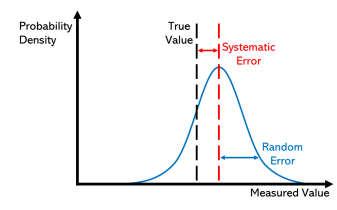

#### Systematic error

A consistent offset to the true value (i.e., a *bias*). In this case of Voyager this results from issues around contamination by the spacecraft's magnetic field and telemetry errors, and comprises the majority of the error term. While it can generally be ignored since any bias is cancelled out when computing increments/fluctuations...

$$(X_1+b) - (X_2+b) = X_1 - X_2$$

...it can still warrant attention when it is not constant over time (i.e., subject to *drift*), as is the case with Voyager data. In this case it introduces low-frequency noise to the statistics, which requires something like a high-pass filter to remove.

#### Random error
Otherwise referred to as **noise**.

##### Effect on PSD

##### Effect on SF

## Sampling error

Results from two things

1. Finite data
2. Sampling variability

Methods of dealing with, in order of rigour:

1. **Use uncertainty of regression fit**, either using standard error or bootstrapping of residuals

    *Quick and easy, but violates assumption of independent errors and only accounts for variability in the fitting procedure, not the physical variability in the flow itself*
    
    *Why is autocorrelation a problem? Because it **reduces the effective sample size**, thereby leading to underestimates of the true uncertainty*

2. **Split interval into sub-intervals** (sub-sampling) and compute SF + params from each

    *Also straightforward. Requires sub-intervals to each contain multiple correlation times.*

3. **Generate synthetic intervals using Moving Block Bootstrap** and compute SF + params from each

    *Has a strong statistical foundation and allows for preserving length of original time series, and therefore better scale coverage. Requires block size to be tuned to correlation time*. 

4. **Generate synthetic SFs using block bootstrap of wavelet leaders** of the original interval and compute params from each

    *Most advanced: tailored for multifractcal processes like turbulence. Requires special wavelet techniques in the case of un-evenly sampled data, but if done properly, this method could be the most robust to missing data.*